# Helmholtz scattering

!!! note "Important points covered in this example"
      - Creating a geometry using the *Gmsh* API
      - Assembling integral operators and integral potentials
      - Setting up a sound-soft problem in both 2 and 3 spatial dimensions
      - Using *GMRES* to solve the linear system
      - Exporting the solution to *Gmsh* for visualization

In this tutorial we will show how to solve an acoustic scattering problem in
the context of Helmholtz equation. We will focus on a *smooth* sound-soft
obstacle for simplicity, and introduce along the way the necessary techniques
used to handle some difficulties encountered. We will use various packages
throughout this example (including of course `Inti.jl`); if they are not on
your environment, you can install them using `] add <package>` in the REPL.

In the following section, we will provide a brief
mathematical description of the problem (valid in both $2$ and $3$
dimensions). We will tackle the [two-dimensional problem](@ref
helmholtz-scattering-2d) first, for which we do not need to worry much about
performance issues (e.g. compressing the integral operators, or exporting the
solution to *Gmsh* for visualization). Finally, we present a three-dimensional
example, where we will use
[`HMatrices.jl`](https://github.com/WaveProp/HMatrices.jl) to compress the
underlying integral operators.

## Sound-soft problem

This example concerns the sound-soft acoustic scattering problem.
Mathematically, this means solving an exterior problem governed by Helmholtz
equation (time-harmonic acoustics) with a Dirichlet boundary condition. More
precisely, letting $\Omega \subset \mathbb{R}^d$ be a bounded domain, and denoting
by $\Gamma = \partial \Omega$ its boundary, we wish to solve

$$
    \Delta u + k^2 u = 0 \quad \text{on} \quad \mathbb{R}^d \setminus \bar{\Omega},
$$

subject to Dirichlet boundary conditions on $\Gamma$

$$
    u(\boldsymbol{x}) = g(\boldsymbol{x}) \quad \text{for} \quad \boldsymbol{x} \in \Gamma.
$$

and the *Sommerfeld radiation condition* at infinity

$$
    \lim_{|\boldsymbol{x}| \to \infty} \|\boldsymbol{x}|^{(d-1)/2} \left( \frac{\partial u}{\partial |\boldsymbol{x}|} - i k u \right) = 0.
$$

Here $g$ is a (given) boundary datum, and $k$ is the constant wavenumber.

For simplicity, we will take $\Gamma$ circle/sphere, and focus on the
*plane-wave scattering* problem. This means we will seek a solution $u$ of
the form $u = u_s + u_i$, where $u_i$ is a known incident field, and
$u_s$ is the scattered field we wish to compute.

!!! note "Complex geometries"
      The main reason for focusing on such a simple example is two-folded. First,
      it alleviates the complexities associated with the mesh generation. Second,
      since exact solutions are known for this problem (in the form of a series),
      it is easy to assess the accuracy of the solution obtained. In practice, you
      can use the same techniques to solve the problem on more complex geometries
      by providing a `.msh` file containing the mesh.

Using the theory of
boundary integral equations, we can express $u_s$ as

$$
    u_s(\boldsymbol{r}) = \mathcal{D}[\sigma](\boldsymbol{r}) - i k \mathcal{S}[\sigma](\boldsymbol{r}),
$$

where $\mathcal{S}$ is the so-called single layer potential, $\mathcal{D}$
is the double-layer potential, and $\sigma : \Gamma \to \mathbb{C}$ is a
surface density. This is an indirect formulation (because $\sigma$ is an
*auxiliary* density, not necessarily physical) commonly referred to as a
*combined field formulation*. Taking the limit $\mathbb{R}^d \setminus \bar
\Omega \ni x \to \Gamma$, it can be shown that the following equation holds
on $\Gamma$:

$$
    \left( \frac{\mathrm{I}}{2} + \mathrm{D} - i k \mathrm{S} \right)[\sigma] = g,
$$

where $\mathrm{I}$ is the identity operator, and $\mathrm{S}$ and $\mathrm{D}$
are the single- and double-layer operators. This is the **combined field
integral equation** that we will solve. The boundary data $g$ is obtained by
applying the sound-soft condition $u=0$ on $\Gamma$, from which it readily
follows that $u_s = -u_i$ on $\Gamma$.

We are now have the necessary background to solve this problem in both 2 and 3
spatial dimensions. Let's load `Inti.jl` and setup some of the (global)
problem parameters:

In [1]:
using Inti

k = 8π
λ = 2π / k
meshsize   = λ / 5
qorder     = 4 # quadrature order
gorder     = 2 # order of geometrical approximation
nothing #hide

## Two-dimensional scattering

We use [Gmsh
API](https://gmsh.info/doc/texinfo/gmsh.html#Gmsh-application-programming-interface)
for creating `.msh` file containing the desired geometry and mesh. Here is a
function to mesh the circle:

In [2]:
using Gmsh # this will trigger the loading of Inti's Gmsh extension

function gmsh_circle(; name, meshsize, order = 1, radius = 1, center = (0, 0))
    try
        gmsh.initialize()
        gmsh.model.add("circle-mesh")
        gmsh.option.setNumber("Mesh.MeshSizeMax", meshsize)
        gmsh.option.setNumber("Mesh.MeshSizeMin", meshsize)
        gmsh.model.occ.addDisk(center[1], center[2], 0, radius, radius)
        gmsh.model.occ.synchronize()
        gmsh.model.mesh.generate(1)
        gmsh.model.mesh.setOrder(order)
        gmsh.write(name)
    finally
        gmsh.finalize()
    end
end

gmsh_circle (generic function with 1 method)

Let us now use `gmsh_circle` to create a `circle.msh` file. As customary in
wave-scattering problems, we will choose a mesh size that is proportional to
wavelength:

In [3]:
name = joinpath(@__DIR__, "circle.msh")
gmsh_circle(; meshsize, order = gorder, name)

Info    : Meshing 1D...
Info    : Meshing curve 1 (Ellipse)
Info    : Done meshing 1D (Wall 0.000231714s, CPU 0.000192s)
Info    : 126 nodes 127 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 50%] Meshing surface 1 order 2
Info    : Done meshing order 2 (Wall 0.00112061s, CPU 0.00112s)
Info    : Writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : Done writing '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'


We can now import the file and parse the mesh and domain information into
`Inti.jl` using the `import_mesh_from_gmsh_file` function:

In [4]:
Ω, msh = Inti.import_mesh_from_gmsh_file(name; dim = 2)
@show Ω

Info    : Reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'...
Info    : 3 entities
Info    : 252 nodes
Info    : 127 elements
Info    : Done reading '/home/lfaria/runner-integral-equations/_work/Inti.jl/Inti.jl/docs/src/examples/generated/circle.msh'
Ω = Domain with 1 entity:
 EntityKey(2,1) --> Inti.GeometricEntity with (dim,tag)=(2,1) and labels String[]


Domain with 1 entity:
 EntityKey(2,1) --> Inti.GeometricEntity with (dim,tag)=(2,1) and labels String[]

In [5]:
@show msh

msh = Inti.LagrangeMesh{2, Float64} containing:
	 1 elements of type StaticArraysCore.SVector{2, Float64}
	 126 elements of type Inti.LagrangeElement{Inti.ReferenceHyperCube{1}, 3, StaticArraysCore.SVector{2, Float64}}


Inti.LagrangeMesh{2, Float64} containing:
	 1 elements of type StaticArraysCore.SVector{2, Float64}
	 126 elements of type Inti.LagrangeElement{Inti.ReferenceHyperCube{1}, 3, StaticArraysCore.SVector{2, Float64}}

The code above will parse all entities in the `name` of dimension `2` as a
`Domain`, and also import the underlying mesh (that, in
this case, is projected into two dimensions by ignoring the third component).
Note that in the example above, `Ω` is a two-dimensional domain containing a
single `GmshEntity` which represents the disk. To extract the boundary $\Gamma
= \partial \Omega$, we can use the `boundary` function:

In [6]:
Γ = Inti.boundary(Ω)

Domain with 1 entity:
 EntityKey(1,1) --> Inti.GeometricEntity with (dim,tag)=(1,1) and labels String[]

To solve our boundary integral equation usign a Nyström method, we actually
need a quadrature of our curve/surface (and possibly the normal vectors at the
quadrature nodes). Once a mesh is available, creating a quadrature object can
be done via the `Quadrature` constructor, which
requires passing a mesh the domain that one wishes to generate a quadrature
for:

In [7]:
Γ = Inti.boundary(Ω)
Γ_msh = view(msh,Γ)
Q = Inti.Quadrature(Γ_msh; qorder)
nothing #hide

!!! tip "Views of a mesh"
      In `Inti.jl`, you can use domain to create a *view* of a mesh containing *only
      the elements in the domain*. For example `view(msh,Γ)` will return an
      `SubMesh` type that you can use to iterate over the elements in the boundary
      of the disk without actually creating a new mesh. You can use `msh[Γ]`,
      or `collect(view(msh,Γ))` to create a new mesh containing *only* the
      elements and nodes in `Γ`.

The object `Q` now contains a quadrature (of order `4`) that can be used to
solve a boundary integral equation on `Γ`. As a sanity check, let's make sure
integrating the function `x->1` over `Q` gives an approximation to the perimeter:

In [8]:
@assert abs(Inti.integrate(x -> 1, Q) - 2π) < 1e-5 #hide
Inti.integrate(x -> 1, Q) - 2π

-4.046297252813247e-8

With the `Quadrature` constructed, we now can define
discrete approximation to the integral operators $\mathrm{S}$ and
$\mathrm{D}$ as follows:

In [9]:
pde = Inti.Helmholtz(; k, dim = 2)
S, D = Inti.single_double_layer(;
    pde,
    target = Q,
    source = Q,
    compression = (method = :none,),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

(ComplexF64[0.0026533898319544063 + 0.001046580456233058im 0.0034805563354252346 + 0.0032324412022761476im … 0.002728527958667407 + 0.0032078950572651836im 0.0019334135174574499 + 0.0010450354339482596im; 0.0011545531921793863 + 0.0010325223843597265im 0.006032767168679149 + 0.0032758934237525524im … 0.0013770109102204577 + 0.003060946159081764im 0.0008712272296526036 + 0.0010242905940836882im; … ; 0.0008712272296525736 + 0.0010242905940836655im 0.0013770109102204337 + 0.0030609461590817106im … 0.0060327671693308944 + 0.0032758934235157674im 0.001154553191924856 + 0.0010325223844565206im; 0.0019334135174574084 + 0.0010450354339482373im 0.002728527958667395 + 0.0032078950572651294im … 0.0034805563360414274 + 0.0032324412019255925im 0.0026533898317172536 + 0.0010465804563710654im], ComplexF64[-0.0003474088196428925 - 3.193002564887076e-6im -0.0010620563104253974 - 3.131075823027224e-5im … -0.0011222145701332614 - 6.768044866564956e-5im -0.0003359104404731084 - 9.862558353014844e-7im; -0.

There are two well-known difficulties related to the discretization of
the boundary integral operators $S$ and $D$:
- The kernel of the integral operator is not smooth, and thus specialized
  quadrature rules are required to accurately approximate the matrix entries for
  which the target and source point lie *close* (relative to some scale) to each
  other.
- The underlying matrix is dense, and thus the storage and computational cost
  of the operator is prohibitive for large problems unless acceleration
  techniques such as *Fast Multipole Methods* or *Hierarchical Matrices* are
  employed.

`Inti.jl` tries to provide a modular and transparent interface for dealing
with both of these difficulties, where the general approach for solving a BIE
will be to first construct a (possible compressed) naive representation of the
integral operator where singular and nearly-singular integrals are ignored,
followed by a the creation of a (sparse) correction intended to account for
such singular interactions. See [`single_double_layer`](@ref
Inti.single_double_layer) for more details on the various options available.

We can now combine `S` and `D` to form the combined-field operator:

In [10]:
using LinearAlgebra
L = I / 2 + D - im * k * S

630×630 Matrix{ComplexF64}:
     0.525956-0.0666902im    …    0.0259287-0.048593im
     0.025604-0.0290296im         0.0253846-0.021918im
    0.0236132-0.00782656im        0.0231248-0.00639229im
     0.020117+0.000803893im       0.0194109+0.00259713im
    0.0173648+0.006155im          0.0165565+0.0065015im
    0.0165566+0.00650158im   …    0.0157322+0.00737868im
    0.0134085+0.00941233im        0.0125253+0.0100405im
   0.00800312+0.0122571im        0.00709557+0.0125237im
   0.00266767+0.0130468im        0.00182098+0.0129989im
 -0.000378962+0.0126372im       -0.00114971+0.0124229im
             ⋮               ⋱  
   0.00182098+0.0129989im        0.00266767+0.0130468im
   0.00709557+0.0125237im        0.00800312+0.0122571im
    0.0125253+0.0100405im         0.0134085+0.00941233im
    0.0157322+0.00737868im        0.0165566+0.00650158im
    0.0165565+0.0065015im    …    0.0173648+0.006155im
    0.0194109+0.00259713im         0.020117+0.000803893im
    0.0231248-0.00639229im        0.023

where `I` is the identity matrix. Assuming an incident field along the $x_1$
direction of the form $u_i =e^{ikx_1}$, the right-hand side of the equation
can be construted using:

In [11]:
uᵢ = x -> exp(im * k * x[1]) # plane-wave incident field
rhs = map(Q) do q
    x = q.coords
    return -uᵢ(x)
end

630-element Vector{ComplexF64}:
 -0.9999999998227967 + 1.882569028297627e-5im
 -0.9999991182591593 + 0.0013279611831148279im
 -0.9999694887615413 + 0.007811628894255199im
 -0.9998061279873904 + 0.01969026253917802im
 -0.9995580452141599 + 0.029727331660401958im
 -0.9994624611177755 + 0.032783971943606605im
 -0.9989675518228854 + 0.04542940022706338im
  -0.997531641049351 + 0.07021841001752205im
 -0.9949551167178109 + 0.10032106317741694im
 -0.9925849060791077 + 0.12155329787352154im
                     ⋮
 -0.9949551167178109 + 0.10032106317741694im
 -0.9975316410493507 + 0.0702184100175256im
 -0.9989675518228854 + 0.04542940022706338im
 -0.9994624611177754 + 0.03278397194361015im
   -0.99955804521416 + 0.02972733166039841im
 -0.9998061279873905 + 0.01969026253917447im
 -0.9999694887615413 + 0.007811628894255199im
 -0.9999991182591593 + 0.0013279611831183806im
 -0.9999999998227967 + 1.882569028297627e-5im

!!! note "Iterating over a quadrature"
      In computing `rhs` above, we used `map` to evaluate the incident field at
      all quadrature nodes. When iterating over `Q`, the iterator returns a
      `QuadratureNode`, and not simply the
      *coordinate* of the quadrature node. This is so that you can access
      additional information, such as the `normal` vector, at the quadrature node.

We can now solve the integral equation using e.g. the backslash operator:

In [12]:
σ = L \ rhs

630-element Vector{ComplexF64}:
  -1.018224623658088 - 0.1179495417054391im
  -1.017721645880051 - 0.11396001840256098im
 -1.0152514769217105 - 0.09449734277559355im
 -1.0108152841516322 - 0.060098901039623065im
 -1.0071510545955051 - 0.03225806272810065im
 -1.0060496638984289 - 0.023996053564489306im
 -1.0015611317897033 + 0.009143388995397156im
 -0.9930480665660066 + 0.06947515896135675im
 -0.9831322216901194 + 0.13513630543780397im
 -0.9763537636343438 + 0.17688238336522344im
                     ⋮
 -0.9831322216901237 + 0.13513630543780575im
 -0.9930480665660052 + 0.06947515896136064im
 -1.0015611317897066 + 0.009143388995400875im
  -1.006049663898432 - 0.023996053564486183im
 -1.0071510545955051 - 0.03225806272809752im
  -1.010815284151634 - 0.0600989010396219im
 -1.0152514769217098 - 0.09449734277559987im
 -1.0177216458800522 - 0.11396001840254857im
 -1.0182246236580859 - 0.11794954170543444im

The variable `σ` contains the value of the approximate density at the
quadrature nodes. To reconstruct a continuous approximation to the solution,
we can use `single_double_layer_potential` to obtain the single- and
double-layer potentials, and then combine them as follows:

In [13]:
𝒮, 𝒟 = Inti.single_double_layer_potential(; pde, source = Q)
uₛ   = x -> 𝒟[σ](x) - im * k * 𝒮[σ](x)

#10 (generic function with 1 method)

The variable `uₛ` is an anonymous/lambda function representing the approximate
scattered field.

To assess the accuracy of the solution, we can compare it to the exact
solution (obtained by separation of variables in polar coordinates):

In [14]:
using SpecialFunctions # for bessel functions

function circle_helmholtz_soundsoft(pt; radius = 1, k, θin)
    x = pt[1]
    y = pt[2]
    r = sqrt(x^2 + y^2)
    θ = atan(y, x)
    u = 0.0
    r < radius && return u
    c(n) = -exp(im * n * (π / 2 - θin)) * besselj(n, k * radius) / besselh(n, k * radius)
    u    = c(0) * besselh(0, k * r)
    n    = 1
    while (abs(c(n)) > 1e-12)
        u +=
            c(n) * besselh(n, k * r) * exp(im * n * θ) +
            c(-n) * besselh(-n, k * r) * exp(-im * n * θ)
        n += 1
    end
    return u
end

circle_helmholtz_soundsoft (generic function with 1 method)

Here is the maximum error on some points located on a circle of radius `2`:

In [15]:
uₑ = x -> circle_helmholtz_soundsoft(x; k, radius = 1, θin = 0) # exact solution
er = maximum(0:0.01:2π) do θ
    R = 2
    x = (R * cos(θ), R * sin(θ))
    return abs(uₛ(x) - uₑ(x))
end
@assert er < 1e-3 #hide
@info "maximum error = $er"

[ Info: maximum error = 1.8832759999564553e-7


As we can see, the error is quite small! To visualize the solution in this
simple (2d) example, we could simply use `Makie`:

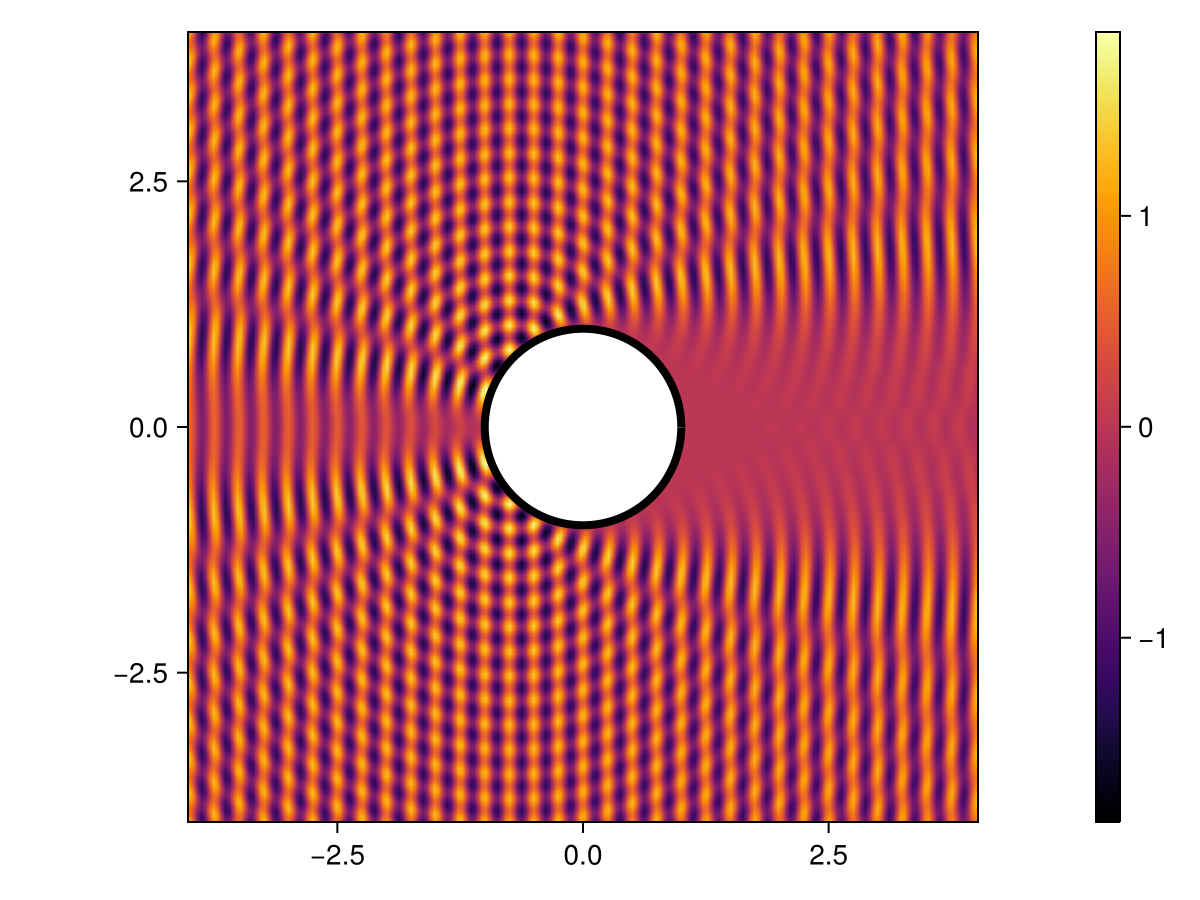

In [16]:
using CairoMakie
xx = yy = range(-4; stop = 4, length = 200)
vals = map(pt -> norm(pt) > 1 ? real(uₛ(pt) + uᵢ(pt)) : NaN, Iterators.product(xx, yy))
fig, ax, hm = heatmap(
    xx,
    yy,
    vals;
    colormap = :inferno,
    interpolate = true,
    axis = (aspect = DataAspect(), xgridvisible = false, ygridvisible = false),
)
lines!(
    ax,
    [cos(θ) for θ in 0:0.01:2π],
    [sin(θ) for θ in 0:0.01:2π];
    color = :black,
    linewidth = 4,
)
Colorbar(fig[1, 2], hm)
fig

More complex problems, however, may require a mesh-based visualization, where
we would first need to create a mesh for the places where we want to visualize
the solution. In the 3D example that follows, we will use the `Gmsh` API to
create a *view* (in the sense of *Gmsh*) of the solution on a punctured plane.

## Three-dimensional scattering

We now consider the same problem in 3D. Unlike the 2D case, assembling dense
matrix representations of the integral operators quickly becomes unfeasiable
as the problem size increases. `Inti` adds support for compressing the
underlying linear operators by wrapping external libraries. In this example,
we will rely on [`HMatrices.jl`](https://github.com/WaveProp/HMatrices.jl) to
handle the compression.

The visualization is also more involved, and we will
use instead the `Gmsh` API to create a view of the solution on a punctured
plane. Let us begin by creating our domain containing both the sphere and the
puctured plane where we will visualize the solution:

In [17]:
function gmsh_sphere(; meshsize, order = gorder, radius = 1, visualize = false, name)
    gmsh.initialize()
    gmsh.model.add("sphere-scattering")
    gmsh.option.setNumber("Mesh.MeshSizeMax", meshsize)
    gmsh.option.setNumber("Mesh.MeshSizeMin", meshsize)
    sphere_tag = gmsh.model.occ.addSphere(0, 0, 0, radius)
    xl,yl,zl = -2*radius,-2*radius,0
    Δx, Δy = 4*radius, 4*radius
    rectangle_tag = gmsh.model.occ.addRectangle(xl, yl, zl, Δx, Δy)
    outDimTags, _ = gmsh.model.occ.cut([(2, rectangle_tag)], [(3, sphere_tag)], -1, true, false)
    gmsh.model.occ.synchronize()
    gmsh.model.addPhysicalGroup(3, [sphere_tag], -1, "omega")
    gmsh.model.addPhysicalGroup(2, [dt[2] for dt in outDimTags], -1, "sigma")
    gmsh.model.mesh.generate(2)
    gmsh.model.mesh.setOrder(order)
    visualize && gmsh.fltk.run()
    gmsh.option.setNumber("Mesh.SaveAll", 1) # otherwise only the physical groups are saved
    gmsh.write(name)
    gmsh.finalize()
end

gmsh_sphere (generic function with 1 method)

As before, lets write a file with our mesh, and import it into `Inti.jl`:

In [18]:
name = joinpath(@__DIR__, "sphere.msh")
gmsh_sphere(; meshsize, order = gorder, name, visualize=false)
Inti.clear_entities!()
Ω, msh = Inti.import_mesh_from_gmsh_file(name; dim = 3)
Γ = Inti.boundary(Ω)

Info    : Meshing 1D...
Info    : [ 20%] Meshing curve 2 (Circle)
Info    : [ 40%] Meshing curve 4 (Line)
Info    : [ 50%] Meshing curve 5 (Line)
Info    : [ 70%] Meshing curve 6 (Line)
Info    : [ 80%] Meshing curve 7 (Line)
Info    : [ 90%] Meshing curve 8 (Circle)
Info    : Done meshing 1D (Wall 0.000792402s, CPU 0.000743s)
Info    : Meshing 2D...
Info    : [  0%] Meshing surface 1 (Sphere, Frontal-Delaunay)
Info    : [ 50%] Meshing surface 2 (Plane, Frontal-Delaunay)
Info    : Done meshing 2D (Wall 0.664301s, CPU 0.664148s)
Info    : 12360 nodes 24786 elements
Info    : Meshing order 2 (curvilinear on)...
Info    : [  0%] Meshing curve 1 order 2
Info    : [ 10%] Meshing curve 2 order 2
Info    : [ 20%] Meshing curve 3 order 2
Info    : [ 30%] Meshing curve 4 order 2
Info    : [ 40%] Meshing curve 5 order 2
Info    : [ 50%] Meshing curve 6 order 2
Info    : [ 60%] Meshing curve 7 order 2
Info    : [ 70%] Meshing curve 8 order 2
Info    : [ 80%] Meshing surface 1 order 2
Info    : [ 

Domain with 1 entity:
 EntityKey(2,1) --> Inti.GeometricEntity with (dim,tag)=(2,1) and labels String[]

Note that for this example we relied instead on the labels to the entities in
order to extract the relevant domains `Ω` and `Σ`. We can now create a
quadrature as before

In [19]:
Γ_msh = view(msh,Γ)
Q = Inti.Quadrature(Γ_msh; qorder = 4)

73080-element Inti.Quadrature{3, Float64}:
 Inti.QuadratureNode{3, Float64}([-0.4734451532020426, 0.535465971849056, 0.6993752963210281], 0.00022827493014403546, [-0.4734404030373813, 0.5354682928525197, 0.6993767883776314])
 Inti.QuadratureNode{3, Float64}([-0.4611085010665634, 0.5440057944822501, 0.7010253763431926], 0.0002282772111988231, [-0.4611114574325287, 0.5440003988376322, 0.7010276669924994])
 Inti.QuadratureNode{3, Float64}([-0.4586422125538417, 0.532385316907492, 0.7114865551254731], 0.0002282745145403388, [-0.4586440428829509, 0.5323886962994576, 0.71148290069442])
 Inti.QuadratureNode{3, Float64}([-0.44488472221067343, 0.5410781324166787, 0.7136609706691894], 0.00011238480450969293, [-0.4448866905813992, 0.5410783735474494, 0.7136596010863843])
 Inti.QuadratureNode{3, Float64}([-0.47142788108816197, 0.5228256512482473, 0.7102176039767786], 0.0001123666112702614, [-0.47142653887933816, 0.5228284488632722, 0.7102164680570796])
 Inti.QuadratureNode{3, Float64}([-0.476645170

!!! tip
      If you pass `visualize=true` to `gmsh_sphere`, it will open a window
      with the current mode. This is done by calling `gmsh.fltk.run()`. Note
      that the main julia thread will be blocked until the window is closed.

!!! tip "Writing/reading a mesh from disk"
      Writing and reading a mesh to/from disk can be time consuming. You can
      avoid doing so by using `import_mesh_from_gmsh_file`
      and `import_mesh_from_gmsh_model` functions on an
      active `gmsh` model without writing it to disk.

We can now assemble the integral operators, indicating that we
wish to compress them using hierarchical matrices:

In [20]:
using HMatrices
pde = Inti.Helmholtz(; k, dim = 3)
S, D = Inti.single_double_layer(;
    pde,
    target = Q,
    source = Q,
    compression = (method = :hmatrix, tol = 1e-6),
    correction = (method = :dim,),
)

(HMatrix of ComplexF64 with range 1:73080 × 1:73080
	 number of nodes in tree: 74901
	 number of leaves: 56176 (18768 admissible + 37408 full)
	 min rank of sparse blocks : 5
	 max rank of sparse blocks : 68
	 min length of dense blocks : 1225
	 max length of dense blocks : 1296
	 min number of elements per leaf: 1225
	 max number of elements per leaf: 20866624
	 depth of tree: 11
	 compression ratio: 22.257272
, HMatrix of ComplexF64 with range 1:73080 × 1:73080
	 number of nodes in tree: 74901
	 number of leaves: 56176 (18768 admissible + 37408 full)
	 min rank of sparse blocks : 7
	 max rank of sparse blocks : 85
	 min length of dense blocks : 1225
	 max length of dense blocks : 1296
	 min number of elements per leaf: 1225
	 max number of elements per leaf: 20866624
	 depth of tree: 11
	 compression ratio: 18.623193
)

Here is how much memory it would take to store the dense representation of
these matrices:

In [21]:
mem = 2 * length(S) * 16 / 1e9 # 16 bytes per complex number, 1e9 bytes per GB, two matrices
println("memory required to store S and D: $(mem) GB")

memory required to store S and D: 170.9019648 GB


Even for this simple example, the dense representation of the integral
operators as matrix is already quite expensive!

!!! note "Compression methods"
      It is worth mentioning that hierchical matrices are not the only way to
      compress such integral operators, and may in fact not even be the best
      for the problem at hand. For example, one could use a fast multipole
      method (FMM), which has a much lighter memory footprint, and is also
      faster to assemble. The main advantage of hierarchical matrices is that
      they are purely algebraic, allowing for the use of *direct solver*.
      Hierarchical matrices also tend to give a faster matrix-vector product
      after the (offline) assembly stage.

We will use the generalized minimal residual (GMRES) iterative solver, for the
linear system. This requires us to define a linear operator `L`, approximating
the combined-field operator, that supports the matrix-vector product. In what
follows we use `LinearMaps` to *lazily* assemble `L`:

In [22]:
using LinearMaps
L = I / 2 + LinearMap(D) - im * k * LinearMap(S)

73080×73080 LinearMaps.LinearCombination{ComplexF64} with 3 maps:
  73080×73080 LinearMaps.ScaledMap{ComplexF64} with scale: -0.0 - 25.132741228718345im of
    73080×73080 LinearMaps.WrappedMap{ComplexF64} of
      73080×73080 HMatrix{ClusterTree{3, Float64}, ComplexF64}
  73080×73080 LinearMaps.UniformScalingMap{Float64} with scaling factor: 0.5
  73080×73080 LinearMaps.WrappedMap{ComplexF64} of
    73080×73080 HMatrix{ClusterTree{3, Float64}, ComplexF64}

Note that wrapping `S` and `D` in `LinearMap` allows for combining them in a
*lazy* fashion. Alternatively, you can use e.g. `axpy!` to add two
hierarchical matrices.

We can now solve the linear system using GMRES solver:

In [23]:
using IterativeSolvers
rhs = map(Q) do q
    x = q.coords
    return -uᵢ(x)
end
σ, hist =
    gmres(L, rhs; log = true, abstol = 1e-6, verbose = false, restart = 100, maxiter = 100)
@show hist

hist = Converged after 22 iterations.


Converged after 22 iterations.

As before, let us represent the solution using `IntegralPotential`s:

In [24]:
𝒮, 𝒟 = Inti.single_double_layer_potential(; pde, source = Q)
uₛ = x -> 𝒟[σ](x) - im * k * 𝒮[σ](x)

#29 (generic function with 1 method)

To check the result, we compare against the exact solution obtained through a
series:

In [25]:
using GSL
sphbesselj(l, r) = sqrt(π / (2r)) * besselj(l + 1 / 2, r)
sphbesselh(l, r) = sqrt(π / (2r)) * besselh(l + 1 / 2, r)
sphharmonic(l, m, θ, ϕ) = GSL.sf_legendre_sphPlm(l, abs(m), cos(θ)) * exp(im * m * ϕ)
function sphere_helmholtz_soundsoft(xobs; radius = 1, k = 1, θin = 0, ϕin = 0)
    x = xobs[1]
    y = xobs[2]
    z = xobs[3]
    r = sqrt(x^2 + y^2 + z^2)
    θ = acos(z / r)
    ϕ = atan(y, x)
    u = 0.0
    r < radius && return u
    function c(l, m)
        return -4π * im^l * sphharmonic(l, -m, θin, ϕin) * sphbesselj(l, k * radius) /
               sphbesselh(l, k * radius)
    end
    l = 0
    for l in 0:60
        for m in -l:l
            u += c(l, m) * sphbesselh(l, k * r) * sphharmonic(l, m, θ, ϕ)
        end
        l += 1
    end
    return u
end

sphere_helmholtz_soundsoft (generic function with 1 method)

We will compute the error on some point on the sphere of radius `2`:

In [26]:
uₑ = (x) -> sphere_helmholtz_soundsoft(x; radius = 1, k = k, θin = π / 2, ϕin = 0)
er = maximum(1:100) do _
    x̂ = rand(Inti.Point3D) |> normalize # an SVector of unit norm
    x = 2 * x̂
    return abs(uₛ(x) - uₑ(x))
end
@assert er < 1e-3 #hide
@info "error with correction = $er"

[ Info: error with correction = 1.618929875296304e-5


We see that, once again, the approximation is quite accurate. Let us now
visualize the solution on the punctured plane (which we labeled as "sigma").
Since evaluating the integral representation of the solution at many points is
expensive, we will use a compression method to accelerate the evaluation as
well. In the example below, we use the fast-multipole method:

In [27]:
using FMM3D

Σ = Inti.Domain(e -> "sigma" ∈ Inti.labels(e), Inti.entities(msh))
Σ_msh = view(msh,Σ)
target = Inti.nodes(Σ_msh)

S,D = Inti.single_double_layer(;
    pde,
    target,
    source = Q,
    compression = (method = :fmm, tol=1e-4),
    correction = (method = :dim, maxdist = 5 * meshsize),
)

ui_eval_msh = uᵢ.(target)
us_eval_msh = D*σ - im*k*S*σ
u_eval_msh = ui_eval_msh + us_eval_msh
nothing #hide

[ Info: Loading Inti.jl FMM3D extension


Finalize, we use gmsh to visualize the scattered field:

In [28]:
gmsh.initialize()
Inti.write_gmsh_model(msh)
Inti.write_gmsh_view!(Σ_msh, real(u_eval_msh); name="sigma real")
Inti.write_gmsh_view!(Γ_msh, x -> 0, name = "gamma real")

Launch the GUI to see the results:

In [29]:
"-nopopup" in ARGS || gmsh.fltk.run()
gmsh.finalize()

Add a gmsh view of the solution and save it:

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*